In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (16, 6)

# Load all 5 stocks
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
stocks = {}

for ticker in tickers:
    df = pd.read_csv(f'../data/raw/{ticker}.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    stocks[ticker] = df
    print(f"{ticker}: {df.shape} | {df.index.min().date()} → {df.index.max().date()}")

print("\nAAPL columns:", stocks['AAPL'].columns.tolist())
print("\nAAPL first 3 rows:")
stocks['AAPL'].head(3)

AAPL: (3774, 5) | 2009-01-02 → 2023-12-29
AMZN: (3774, 5) | 2009-01-02 → 2023-12-29
GOOG: (3774, 5) | 2009-01-02 → 2023-12-29
META: (2923, 5) | 2012-05-18 → 2023-12-29
NVDA: (3774, 5) | 2009-01-02 → 2023-12-29

AAPL columns: ['Close', 'High', 'Low', 'Open', 'Volume']

AAPL first 3 rows:


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400


In [2]:
def compute_indicators(df):
    # SMA
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()

    # EMA
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

    # MACD
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

    # RSI
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    return df

# Apply to all stocks
for ticker in tickers:
    stocks[ticker] = compute_indicators(stocks[ticker])
    print(f"{ticker} indicators computed ✓")

print("\nAAPL new columns:", stocks['AAPL'].columns.tolist())

AAPL indicators computed ✓
AMZN indicators computed ✓
GOOG indicators computed ✓
META indicators computed ✓
NVDA indicators computed ✓

AAPL new columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI']


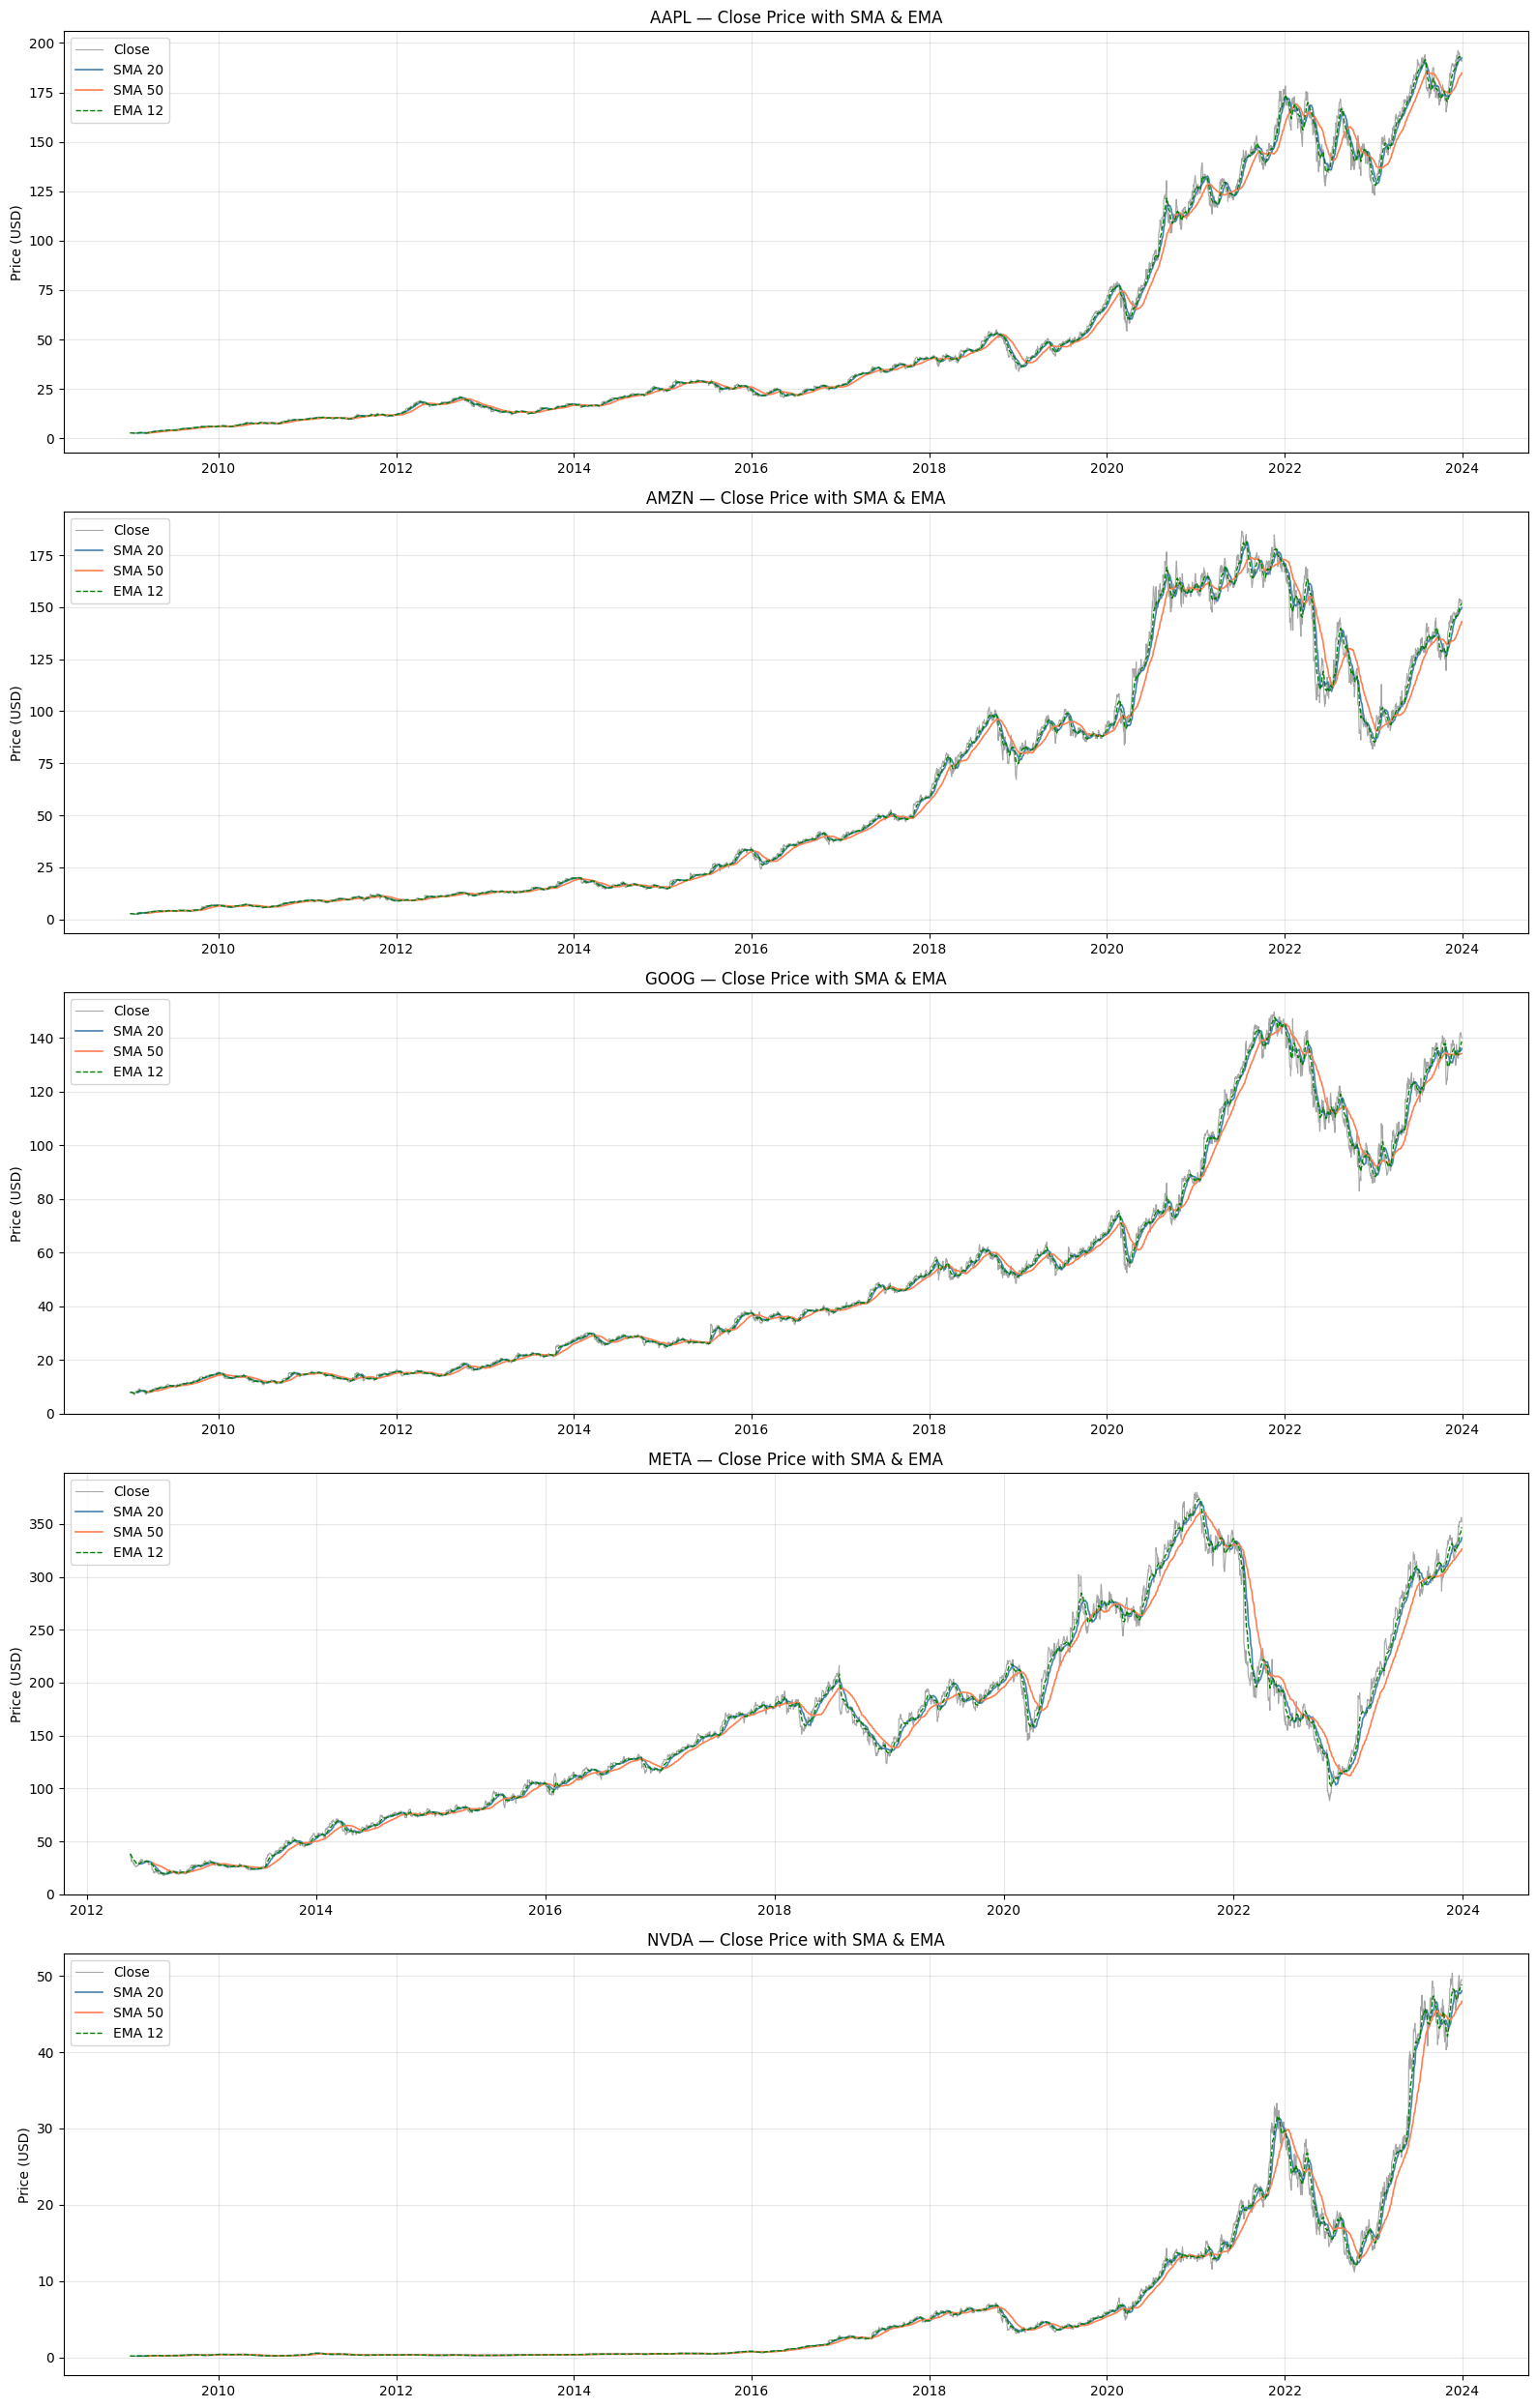

SMA/EMA plot saved.


In [3]:
fig, axes = plt.subplots(5, 1, figsize=(16, 25))

for i, ticker in enumerate(tickers):
    df = stocks[ticker]
    axes[i].plot(df['Close'], label='Close', color='gray', linewidth=0.8, alpha=0.7)
    axes[i].plot(df['SMA_20'], label='SMA 20', color='steelblue', linewidth=1.2)
    axes[i].plot(df['SMA_50'], label='SMA 50', color='coral', linewidth=1.2)
    axes[i].plot(df['EMA_12'], label='EMA 12', color='green', linewidth=1.0, linestyle='--')
    axes[i].set_title(f'{ticker} — Close Price with SMA & EMA')
    axes[i].set_ylabel('Price (USD)')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/raw/sma_ema_all_stocks.png', dpi=150)
plt.show()
print("SMA/EMA plot saved.")

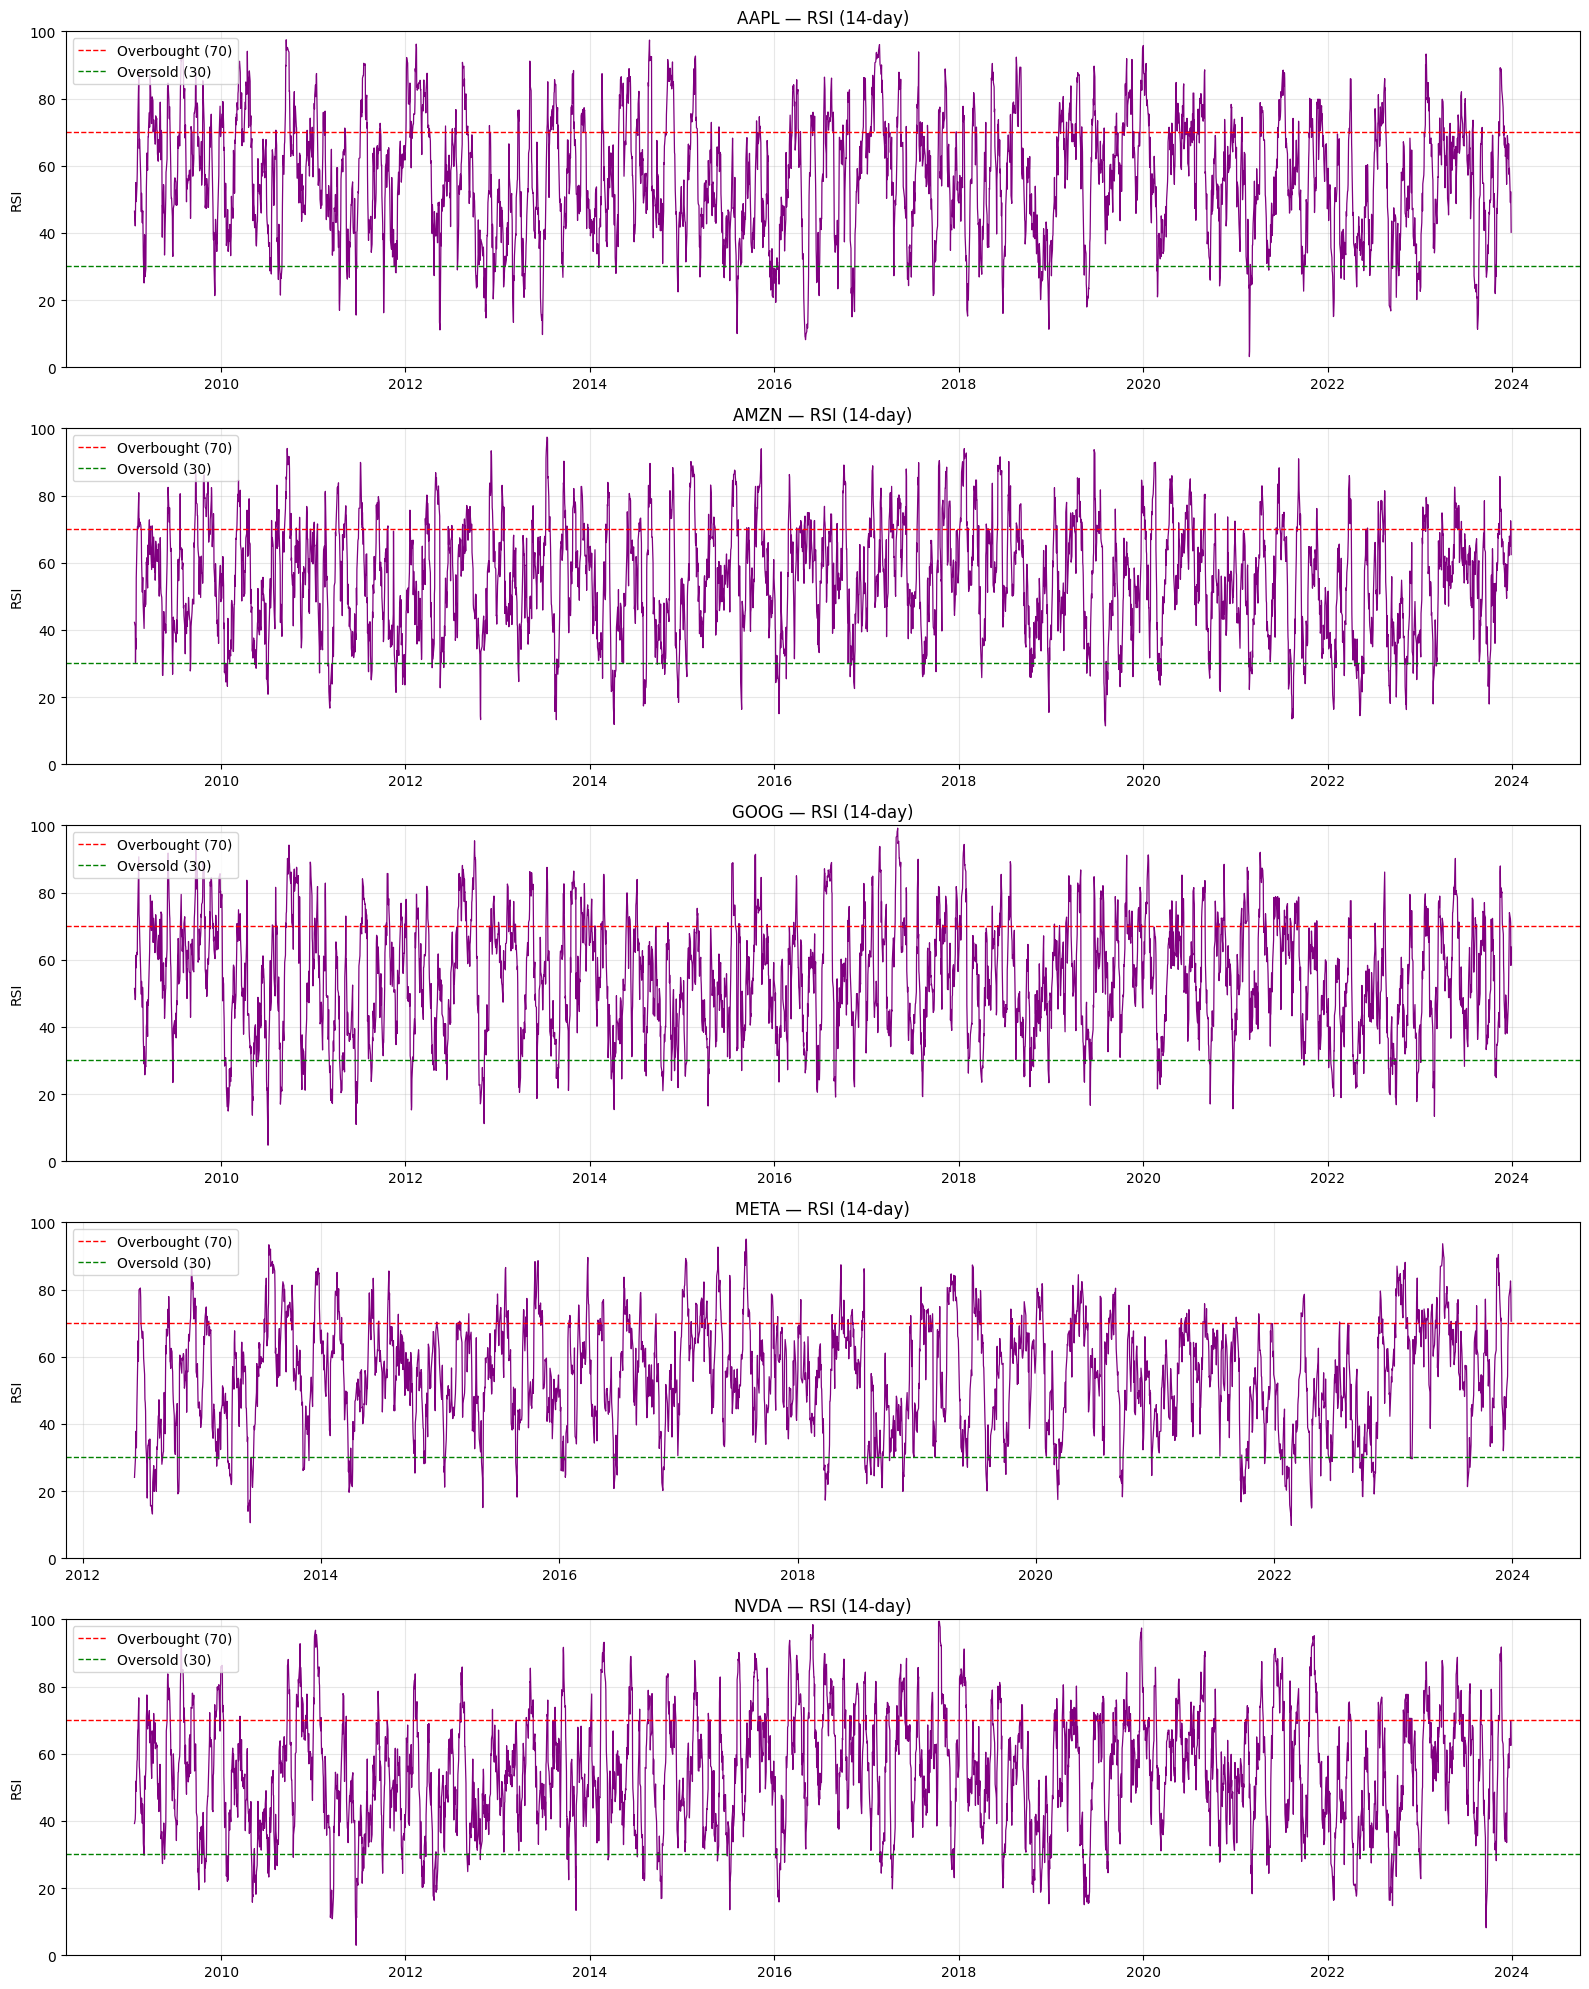

RSI plot saved.


In [4]:
fig, axes = plt.subplots(5, 1, figsize=(16, 20))

for i, ticker in enumerate(tickers):
    df = stocks[ticker]
    axes[i].plot(df['RSI'], color='purple', linewidth=0.9)
    axes[i].axhline(70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
    axes[i].axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
    axes[i].set_title(f'{ticker} — RSI (14-day)')
    axes[i].set_ylabel('RSI')
    axes[i].set_ylim(0, 100)
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/raw/rsi_all_stocks.png', dpi=150)
plt.show()
print("RSI plot saved.")

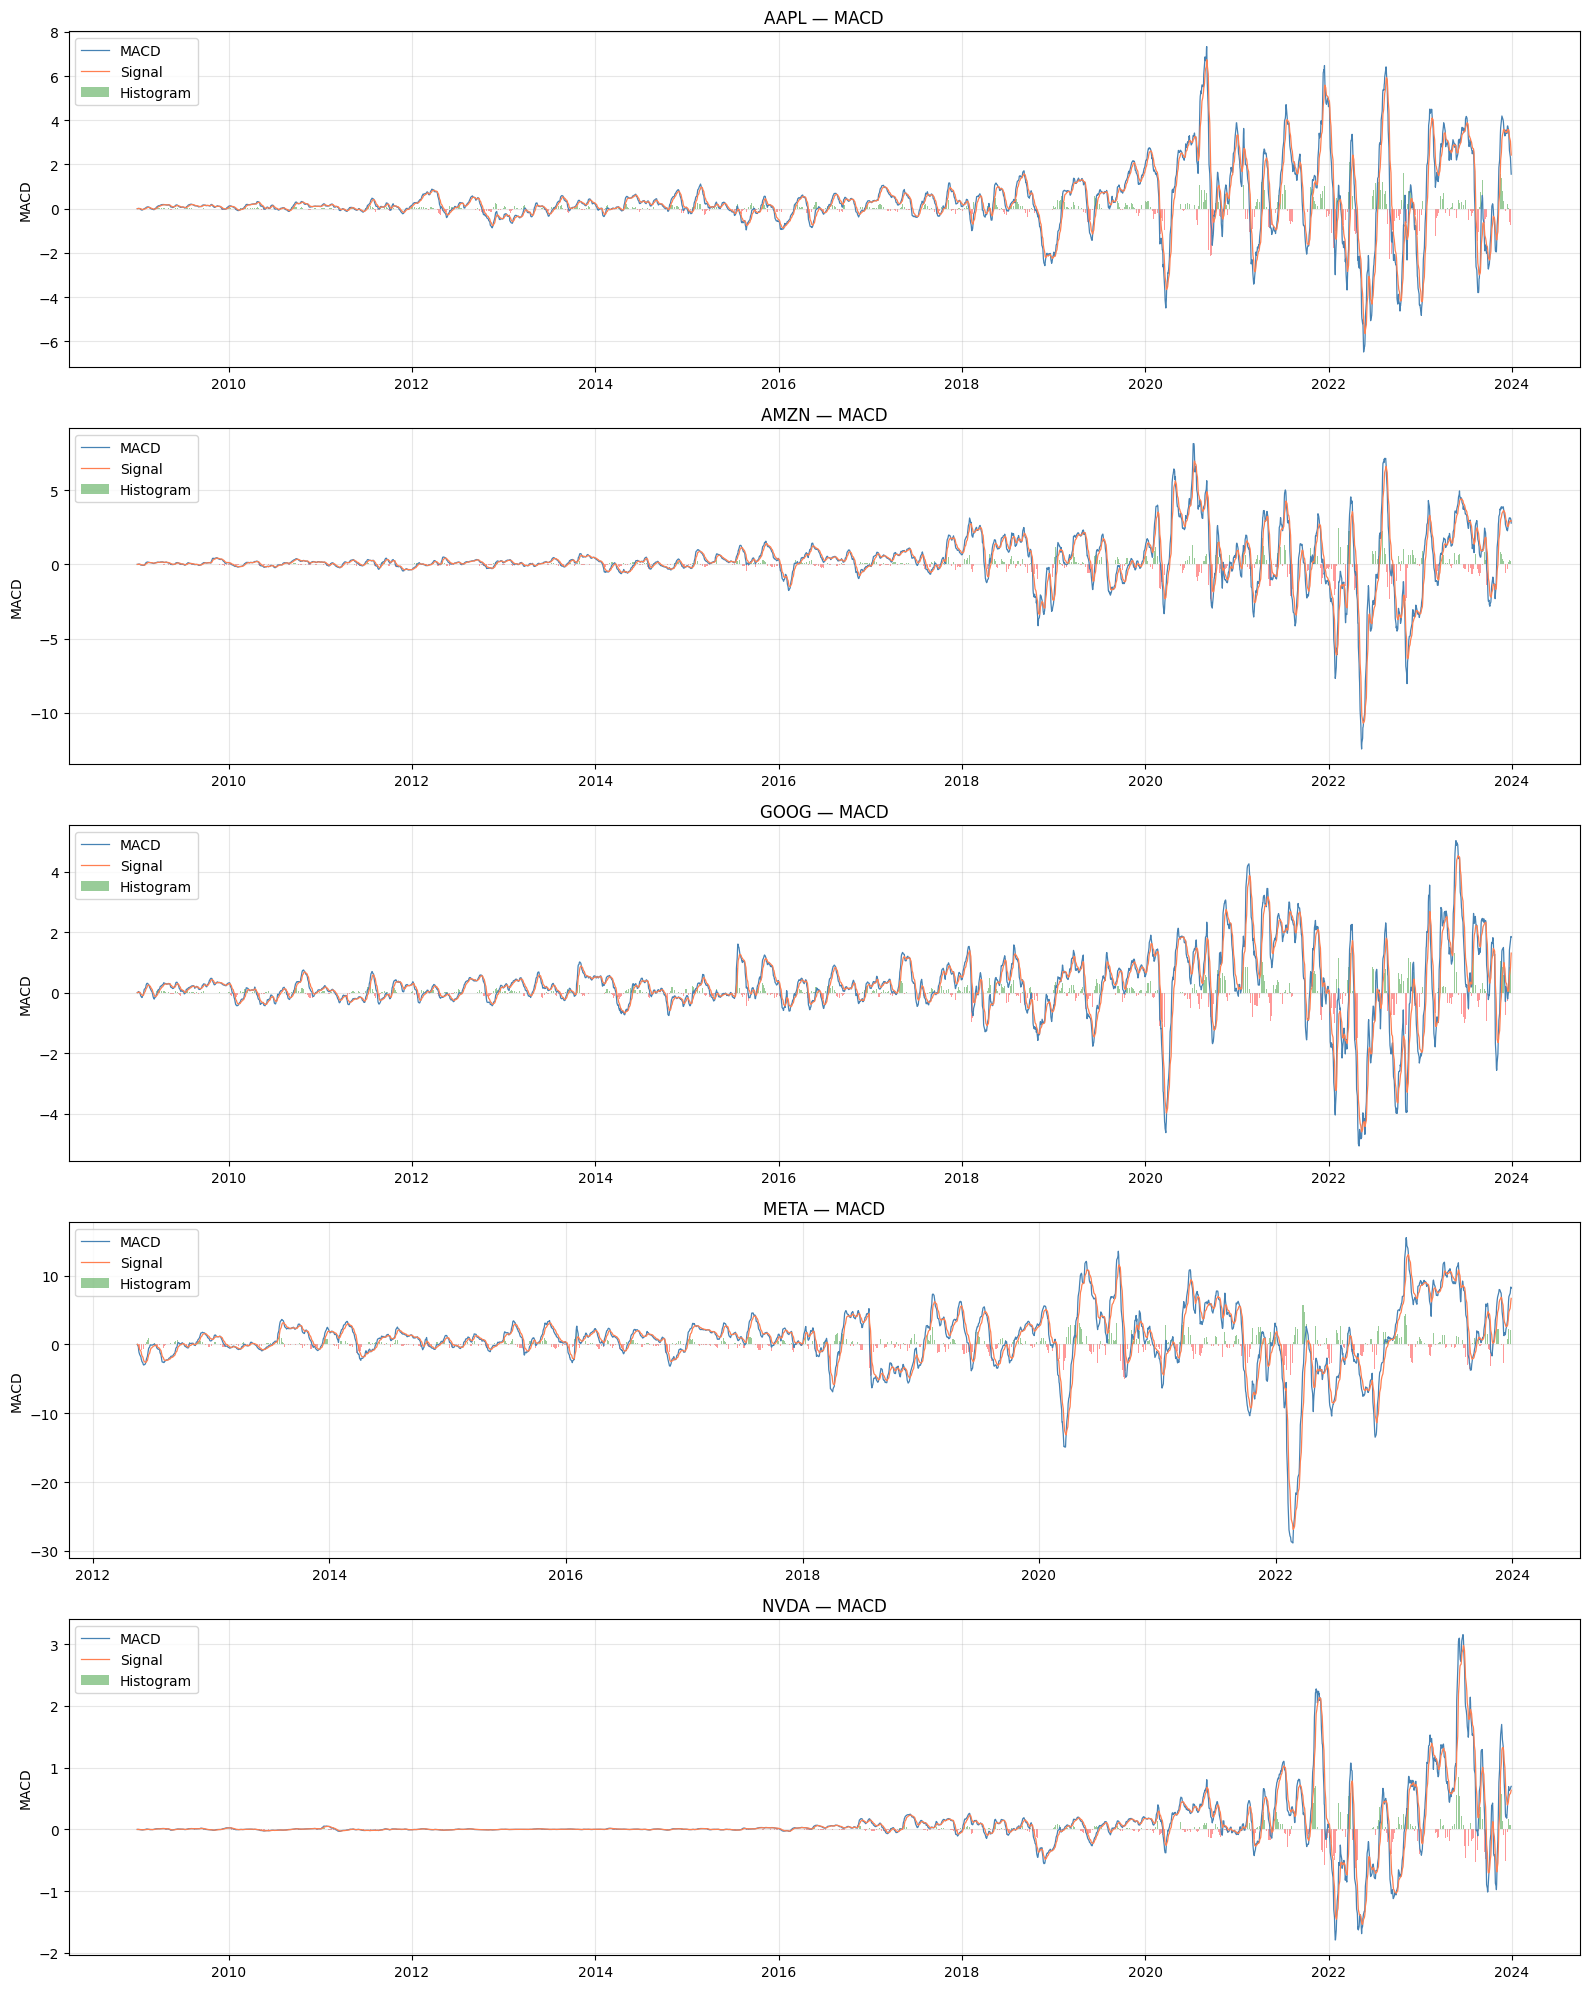

MACD plot saved.


In [5]:
fig, axes = plt.subplots(5, 1, figsize=(16, 20))

for i, ticker in enumerate(tickers):
    df = stocks[ticker]
    axes[i].plot(df['MACD'], label='MACD', color='steelblue', linewidth=0.9)
    axes[i].plot(df['MACD_Signal'], label='Signal', color='coral', linewidth=0.9)
    axes[i].bar(df.index, df['MACD_Hist'],
                color=df['MACD_Hist'].apply(lambda x: 'green' if x >= 0 else 'red'),
                alpha=0.4, label='Histogram')
    axes[i].set_title(f'{ticker} — MACD')
    axes[i].set_ylabel('MACD')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/raw/macd_all_stocks.png', dpi=150)
plt.show()
print("MACD plot saved.")

In [6]:
print("=== Indicator Summary (Latest Values) ===\n")
summary = []

for ticker in tickers:
    latest = stocks[ticker].iloc[-1]
    summary.append({
        'Ticker': ticker,
        'Close': round(latest['Close'], 2),
        'SMA_20': round(latest['SMA_20'], 2),
        'SMA_50': round(latest['SMA_50'], 2),
        'RSI': round(latest['RSI'], 2),
        'MACD': round(latest['MACD'], 4),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df

=== Indicator Summary (Latest Values) ===

Ticker  Close  SMA_20  SMA_50   RSI   MACD
  AAPL 190.73  192.49  184.81 40.19 1.5595
  AMZN 151.94  149.82  143.05 62.42 2.7820
  GOOG 139.97  135.98  134.06 63.74 1.8428
  META 351.79  336.87  326.26 70.56 8.1933
  NVDA  49.50   48.05   46.66 62.56 0.6975


,Ticker,Close,SMA_20,SMA_50,RSI,MACD
0,AAPL,190.73,192.49,184.81,40.19,1.5595
1,AMZN,151.94,149.82,143.05,62.42,2.7820
2,GOOG,139.97,135.98,134.06,63.74,1.8428
3,META,351.79,336.87,326.26,70.56,8.1933
4,NVDA,49.50,48.05,46.66,62.56,0.6975
